# dp-CO$_2$ metrics benchmark notebook with uncertainty bands

This notebook extends the unified **dp-CO$_2$ approach** workflow to include:
- central trajectories from the point-value sheets
- uncertainty envelopes from the `*_wh_ensmb_*` sheets
- flexible band options:
  - percentile band, e.g. P5–P95
  - absolute min/max across the 1001 ensemble

It supports three metric families through one selector:
- `gwp`
- `rf`
- `agwp`


In [1]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10')


## configuration

In [2]:
# ---- choose metric family ----
METRIC_KIND = "gwp"   # options: "gwp", "rf", "agwp"
EXPORT_OUTPUTS = False

# ---- uncertainty band configuration ----
UNCERTAINTY_MODE = "percentile"   # options: "percentile", "minmax"
P_LOW = 5
P_HIGH = 95
BAND_ALPHA = 0.12
LINEWIDTH = 1.8

# horizon setup
len_cf = 101
HORIZON_YEARS = np.arange(len_cf)

# scenarios and model years
ssps = ["119", "245", "585"]
MYs = [2030, 2040, 2050]
ghggass = ["CO2", "CH4", "N2O"]

# metric directories
metric_dir_modB = "../FaIR_dpCFs/output/metrics_2026-02-23/"
metric_dir_modC = "../FaIR_dpCFs/output/metrics_AGWP_wh_ModC_CC_T/"

# workbook naming template
filename_template_modB = "agwp_dcf_gwp100_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"
filename_template_modC = "agwp_by_pIRF_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

# plotting style
ssp_labels = {"119": "SSP1-1.9", "245": "SSP2-4.5", "585": "SSP5-8.5"}
ssp_colors = {"119": "#43dde6", "245": "#364f6b", "585": "#fc5185"}


In [3]:
def get_metric_meta(metric_kind: str):
    metric_kind = metric_kind.lower()

    if metric_kind == "gwp":
        return {
            "sheet_template": "gwp_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "gwp_wh_ensmb_{gas}{MY}",
            "suffix": "GWP",
            "value_label": "dpGWP",
            "panel_ylabel": "dpGWP (dp-CO$_2$)",
            "suptitle": "Benchmark of dp-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dpGWP_dpCO2",
            "nc_stub": "GWP",
        }
    elif metric_kind == "rf":
        return {
            "sheet_template": "rf_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "rf_wh_ensmb_{gas}{MY}",
            "suffix": "RF",
            "value_label": "instantaneous RF",
            "panel_ylabel": "Instantaneous RF",
            "suptitle": "Benchmark of dp-CO$_2$ instantaneous RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dRF_dpCO2",
            "nc_stub": "RF",
        }
    elif metric_kind == "agwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "agwp_wh_ensmb_{gas}{MY}",
            "suffix": "AGWP",
            "value_label": "cumulative RF",
            "panel_ylabel": "Cumulative RF",
            "suptitle": "Benchmark of dp-CO$_2$ cumulative RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dCRF_dpCO2",
            "nc_stub": "CRF",
        }
    else:
        raise ValueError("METRIC_KIND must be one of: 'gwp', 'rf', 'agwp'")


META = get_metric_meta(METRIC_KIND)
META

{'sheet_template': 'gwp_pointvalue{gas}_{MY}',
 'ensmb_sheet_template': 'gwp_wh_ensmb_{gas}{MY}',
 'suffix': 'GWP',
 'value_label': 'dpGWP',
 'panel_ylabel': 'dpGWP (dp-CO$_2$)',
 'suptitle': 'Benchmark of dp-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)',
 'export_stub': 'dpGWP_dpCO2',
 'nc_stub': 'GWP'}

## helper functions

In [4]:

def _read_numeric_vector_from_pointvalue(cf_file, sheet_name, gas, len_cf=101):
    cf_df = pd.read_excel(cf_file, sheet_name=sheet_name)
    if gas in cf_df.columns:
        vals = pd.to_numeric(cf_df[gas], errors="coerce").to_numpy()
    else:
        # fall back to first numeric column
        num_df = cf_df.apply(pd.to_numeric, errors="coerce")
        vals = num_df.select_dtypes(include=[np.number]).iloc[:, 0].to_numpy()
    return np.asarray(vals[:len_cf], dtype=float)


def _read_numeric_matrix_from_ensemble(cf_file, sheet_name, len_cf=101):
    ens_df = pd.read_excel(cf_file, sheet_name=sheet_name, index_col=0)
    ens_df = ens_df.apply(pd.to_numeric, errors="coerce")
    ens_df = ens_df.dropna(axis=1, how="all")
    mat = ens_df.to_numpy(dtype=float)

    if mat.shape[0] < len_cf and mat.shape[1] >= len_cf:
        mat = mat.T

    if mat.shape[0] < len_cf:
        raise ValueError(f"{cf_file.name}::{sheet_name} has only {mat.shape[0]} rows; expected at least {len_cf}")

    return np.asarray(mat[:len_cf, :], dtype=float)


def load_metric_pointvalue_dict(metric_dir, filename_template, ghg_list, ssps, MYs, sheet_template, len_cf=101):
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                cf_file = metric_dir / filename_template.format(gas=gas, ssp=sp, MY=MY)
                sheet_name = sheet_template.format(gas=gas, MY=MY)
                out[gas][f"ssp{sp}"][str(MY)] = _read_numeric_vector_from_pointvalue(
                    cf_file=cf_file, sheet_name=sheet_name, gas=gas, len_cf=len_cf
                )
    return out


def load_metric_ensemble_dict(metric_dir, filename_template, ghg_list, ssps, MYs, ensmb_sheet_template, len_cf=101):
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                cf_file = metric_dir / filename_template.format(gas=gas, ssp=sp, MY=MY)
                sheet_name = ensmb_sheet_template.format(gas=gas, MY=MY)
                out[gas][f"ssp{sp}"][str(MY)] = _read_numeric_matrix_from_ensemble(
                    cf_file=cf_file, sheet_name=sheet_name, len_cf=len_cf
                )
    return out


def build_metric_dataframe(metric_results, metric_suffix, strip_ssp_prefix=False, integer_dims=False, prepend_zero_row=False):
    records = []

    ref_gas = list(metric_results.keys())[0]
    for ssp in metric_results[ref_gas].keys():
        for my in metric_results[ref_gas][ssp].keys():
            arr_len = len(metric_results[ref_gas][ssp][my])

            if prepend_zero_row:
                row0 = {"SSP": ssp, "ModelYear": my, "Year": 0}
                for gas in metric_results.keys():
                    row0[f"{gas}_{metric_suffix}"] = 0.0
                records.append(row0)
                year_start = 1
            else:
                year_start = 0

            for i in range(arr_len):
                row = {"SSP": ssp, "ModelYear": my, "Year": year_start + i}
                for gas in metric_results.keys():
                    row[f"{gas}_{metric_suffix}"] = metric_results[gas][ssp][my][i]
                records.append(row)

    df_out = pd.DataFrame(records)

    if strip_ssp_prefix:
        df_out["SSP"] = df_out["SSP"].astype(str).str.replace("ssp", "", regex=False)

    if integer_dims:
        df_out["ModelYear"] = pd.to_numeric(df_out["ModelYear"], errors="coerce").astype(int)
        df_out["Year"] = pd.to_numeric(df_out["Year"], errors="coerce").astype(int)

    return df_out.set_index(["SSP", "ModelYear", "Year"]).sort_index()



def build_uncertainty_long_df(metric_ensemble_results, metric_suffix, prepend_zero_row=False):
    records = []
    ref_gas = list(metric_ensemble_results.keys())[0]

    for ssp in metric_ensemble_results[ref_gas].keys():
        for my in metric_ensemble_results[ref_gas][ssp].keys():
            mat_ref = np.asarray(metric_ensemble_results[ref_gas][ssp][my], dtype=float)
            n_years, n_ens = mat_ref.shape

            if prepend_zero_row:
                for gas in metric_ensemble_results.keys():
                    records.append({
                        "SSP": ssp.replace("ssp", ""),
                        "ModelYear": int(my),
                        "Year": 0,
                        "Gas": gas,
                        "lower": 0.0,
                        "upper": 0.0,
                        "central": 0.0,
                        "n_ens": int(n_ens),
                    })
                year_offset = 1
            else:
                year_offset = 0

            for gas in metric_ensemble_results.keys():
                mat = np.asarray(metric_ensemble_results[gas][ssp][my], dtype=float)

                for i in range(mat.shape[0]):
                    vals = np.asarray(mat[i, :], dtype=float)
                    vals = vals[np.isfinite(vals)]

                    if vals.size == 0:
                        lower = np.nan
                        upper = np.nan
                        central = np.nan
                        n_eff = 0
                    else:
                        if UNCERTAINTY_MODE == "percentile":
                            lower = float(np.nanpercentile(vals, P_LOW))
                            upper = float(np.nanpercentile(vals, P_HIGH))
                        elif UNCERTAINTY_MODE == "minmax":
                            lower = float(np.nanmin(vals))
                            upper = float(np.nanmax(vals))
                        else:
                            raise ValueError("UNCERTAINTY_MODE must be 'percentile' or 'minmax'")

                        central = float(np.nanmedian(vals))
                        n_eff = int(vals.size)

                    records.append({
                        "SSP": ssp.replace("ssp", ""),
                        "ModelYear": int(my),
                        "Year": int(year_offset + i),
                        "Gas": gas,
                        "lower": lower,
                        "upper": upper,
                        "central": central,
                        "n_ens": n_eff,
                    })

    df = pd.DataFrame(records).sort_values(["Gas", "SSP", "ModelYear", "Year"]).reset_index(drop=True)

    # hard enforce numeric dtypes
    for col in ["ModelYear", "Year", "lower", "upper", "central", "n_ens"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ModelYear"] = df["ModelYear"].astype("Int64")
    df["Year"] = df["Year"].astype("Int64")
    df["n_ens"] = df["n_ens"].astype("Int64")

    return df




def export_metric_outputs(df_formatted, out_dir, excel_name, nc_name_full, nc_name_hpos):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_formatted.to_excel(out_dir / excel_name, index=True)

    xr_full = df_formatted.to_xarray()
    xr_full.to_netcdf(out_dir / nc_name_full)

    df_hpos = df_formatted[~(df_formatted.index.get_level_values("Year") == 0)].copy()
    xr_hpos = df_hpos.to_xarray()
    xr_hpos.to_netcdf(out_dir / nc_name_hpos)

    return df_hpos, xr_full, xr_hpos


def wide_to_long_for_benchmark(df_wide, metric_suffix, value_label, approach_name):
    value_cols = [f"CO2_{metric_suffix}", f"CH4_{metric_suffix}", f"N2O_{metric_suffix}"]

    long_df = (
        df_wide
        .reset_index()
        .melt(
            id_vars=["SSP", "ModelYear", "Year"],
            value_vars=value_cols,
            var_name="Gas",
            value_name=value_label,
        )
    )
    long_df["Gas"] = long_df["Gas"].str.replace(f"_{metric_suffix}", "", regex=False)
    long_df["Approach"] = approach_name
    return long_df


def standardize_benchmark_keys(df_long):
    df_long = df_long.copy()
    df_long["SSP"] = df_long["SSP"].astype(str).str.strip().str.replace("ssp", "", regex=False)
    df_long["Gas"] = df_long["Gas"].astype(str).str.strip()
    df_long["ModelYear"] = pd.to_numeric(df_long["ModelYear"], errors="coerce").astype("Int64")
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype("Int64")
    return df_long


def build_benchmark_dataframe(df_modB, df_modC, metric_suffix, value_label):
    long_modB = standardize_benchmark_keys(
        wide_to_long_for_benchmark(df_modB, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module B")
    )
    long_modC = standardize_benchmark_keys(
        wide_to_long_for_benchmark(df_modC, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module C")
    )

    bench = (
        long_modB
        .merge(
            long_modC,
            on=["SSP", "ModelYear", "Year", "Gas"],
            suffixes=("_ModB", "_ModC"),
            how="inner",
            validate="one_to_one",
        )
        .drop(columns=["Approach_ModB", "Approach_ModC"])
    )

    bench["abs_diff"] = bench[f"{value_label}_ModC"] - bench[f"{value_label}_ModB"]
    bench["abs_diff_abs"] = bench["abs_diff"].abs()
    bench["pct_diff_vs_ModB"] = np.where(
        bench[f"{value_label}_ModB"] != 0,
        100 * bench["abs_diff"] / bench[f"{value_label}_ModB"],
        np.nan,
    )
    bench["pct_diff_abs"] = bench["pct_diff_vs_ModB"].abs()
    return bench




def build_benchmark_uncertainty_dataframe(unc_modB, unc_modC):
    uB = standardize_benchmark_keys(unc_modB)
    uC = standardize_benchmark_keys(unc_modC)

    bench_u = (
        uB.merge(
            uC,
            on=["SSP", "ModelYear", "Year", "Gas"],
            suffixes=("_ModB", "_ModC"),
            how="inner",
            validate="one_to_one",
        )
    )

    # hard enforce numeric dtypes after merge
    for col in [
        "ModelYear", "Year",
        "lower_ModB", "upper_ModB", "central_ModB", "n_ens_ModB",
        "lower_ModC", "upper_ModC", "central_ModC", "n_ens_ModC",
    ]:
        if col in bench_u.columns:
            bench_u[col] = pd.to_numeric(bench_u[col], errors="coerce")

    bench_u["ModelYear"] = bench_u["ModelYear"].astype("Int64")
    bench_u["Year"] = bench_u["Year"].astype("Int64")

    return bench_u







def summarize_benchmark(benchmark_df, value_label):
    summary_stats = (
        benchmark_df[benchmark_df["Year"] > 0]
        .groupby(["Gas", "SSP", "ModelYear"], as_index=False)
        .agg(
            mean_ModB=(f"{value_label}_ModB", "mean"),
            mean_ModC=(f"{value_label}_ModC", "mean"),
            mean_abs_diff=("abs_diff", "mean"),
            mean_abs_diff_abs=("abs_diff_abs", "mean"),
            max_abs_diff_abs=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff_abs=("pct_diff_abs", "max"),
        )
    )

    for H in [20, 50, 100]:
        tmp = benchmark_df[benchmark_df["Year"] == H][["Gas", "SSP", "ModelYear", f"{value_label}_ModB", f"{value_label}_ModC", "abs_diff", "pct_diff_vs_ModB"]].copy()
        tmp = tmp.rename(columns={
            f"{value_label}_ModB": f"ModB_H{H}",
            f"{value_label}_ModC": f"ModC_H{H}",
            "abs_diff": f"abs_diff_H{H}",
            "pct_diff_vs_ModB": f"pct_diff_H{H}",
        })
        summary_stats = summary_stats.merge(tmp, on=["Gas", "SSP", "ModelYear"], how="left")

    summary_stats = summary_stats.sort_values(["Gas", "ModelYear", "SSP"]).reset_index(drop=True)

    summary_by_gas = (
        benchmark_df[benchmark_df["Year"] > 0]
        .groupby("Gas", as_index=False)
        .agg(
            mean_ModB=(f"{value_label}_ModB", "mean"),
            mean_ModC=(f"{value_label}_ModC", "mean"),
            mean_abs_diff=("abs_diff", "mean"),
            max_abs_diff_abs=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff_abs=("pct_diff_abs", "max"),
        )
    )

    return summary_stats, summary_by_gas


def _band_label():
    if UNCERTAINTY_MODE == "percentile":
        return f"P{P_LOW}–P{P_HIGH}"
    return "Min–Max"




def plot_single_metric_panels_with_uncertainty(df_metric, df_unc, ylabel, gas_order=None, my_order=None):
    gas_order = gas_order or ["CO2", "CH4", "N2O"]
    my_order = my_order or [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    df_plot = df_metric.reset_index().copy()
    for col in ["ModelYear", "Year", "value"]:
        if col in df_plot.columns:
            df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

    df_unc_plot = df_unc.copy()
    for col in ["ModelYear", "Year", "lower", "upper", "central"]:
        if col in df_unc_plot.columns:
            df_unc_plot[col] = pd.to_numeric(df_unc_plot[col], errors="coerce")

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = df_plot[(df_plot["Gas"] == gas) & (df_plot["ModelYear"] == my)].copy()
            sub_u = df_unc_plot[(df_unc_plot["Gas"] == gas) & (df_unc_plot["ModelYear"] == my)].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                su = sub_u[sub_u["SSP"] == ssp].sort_values("Year")

                if s.empty:
                    continue

                color = ssp_colors[ssp]

                if not su.empty:
                    su = su.dropna(subset=["Year", "lower", "upper"]).copy()
                    su = su.sort_values("Year")

                    x = su["Year"].to_numpy(dtype=float)
                    y1 = su["lower"].to_numpy(dtype=float)
                    y2 = su["upper"].to_numpy(dtype=float)

                    if len(x) > 0:
                        ax.fill_between(x, y1, y2, color=color, alpha=BAND_ALPHA, linewidth=0)

                s = s.dropna(subset=["Year", "value"]).copy()
                x_line = s["Year"].to_numpy(dtype=float)
                y_line = s["value"].to_numpy(dtype=float)
                ax.plot(x_line, y_line, color=color, linewidth=LINEWIDTH)

            ax.set_title(f"{gas}, MY={my}", fontsize=11)
            ax.set_xlabel("Time after emission")
            if c == 0:
                ax.set_ylabel(ylabel)
            ax.grid(False)

    ssp_handles = [Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k]) for k in ["119", "245", "585"]]
    band_handles = [Line2D([0], [0], color="black", lw=6, alpha=BAND_ALPHA, label=_band_label())]

    fig.legend(
        handles=ssp_handles,
        loc="upper center",
        fontsize=12,
        bbox_to_anchor=(0.34, 0.95),
        ncol=3,
        frameon=True,
        title="Scenario"
    )
    fig.legend(
        handles=band_handles,
        loc="upper center",
        fontsize=12,
        bbox_to_anchor=(0.74, 0.95),
        ncol=1,
        frameon=True,
        title="Uncertainty band"
    )

    fig.subplots_adjust(top=0.86, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()


def plot_benchmark_3x3_with_uncertainty(benchmark_df, benchmark_unc_df, value_label, panel_ylabel, suptitle, gas_order=None, my_order=None):
    gas_order = gas_order or ["CO2", "CH4", "N2O"]
    my_order = my_order or [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    df_plot = benchmark_df.copy()
    for col in ["ModelYear", "Year", f"{value_label}_ModB", f"{value_label}_ModC"]:
        if col in df_plot.columns:
            df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

    df_unc_plot = benchmark_unc_df.copy()
    for col in ["ModelYear", "Year", "lower_ModB", "upper_ModB", "lower_ModC", "upper_ModC"]:
        if col in df_unc_plot.columns:
            df_unc_plot[col] = pd.to_numeric(df_unc_plot[col], errors="coerce")

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = df_plot[
                (df_plot["Gas"] == gas) &
                (df_plot["ModelYear"] == my) &
                (df_plot["Year"] > 0)
            ].copy()

            sub_u = df_unc_plot[
                (df_unc_plot["Gas"] == gas) &
                (df_unc_plot["ModelYear"] == my) &
                (df_unc_plot["Year"] > 0)
            ].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                su = sub_u[sub_u["SSP"] == ssp].sort_values("Year")

                if s.empty:
                    continue

                color = ssp_colors[ssp]

                if not su.empty:
                    su = su.dropna(subset=["Year", "lower_ModB", "upper_ModB", "lower_ModC", "upper_ModC"]).copy()
                    su = su.sort_values("Year")

                    x = su["Year"].to_numpy(dtype=float)

                    y1_b = su["lower_ModB"].to_numpy(dtype=float)
                    y2_b = su["upper_ModB"].to_numpy(dtype=float)
                    y1_c = su["lower_ModC"].to_numpy(dtype=float)
                    y2_c = su["upper_ModC"].to_numpy(dtype=float)

                    if len(x) > 0:
                        ax.fill_between(x, y1_b, y2_b, color=color, alpha=BAND_ALPHA * 0.7, linewidth=0)
                        ax.fill_between(x, y1_c, y2_c, color=color, alpha=BAND_ALPHA, linewidth=0)

                s = s.dropna(subset=["Year", f"{value_label}_ModB", f"{value_label}_ModC"]).copy()

                x_line = s["Year"].to_numpy(dtype=float)
                y_modb = s[f"{value_label}_ModB"].to_numpy(dtype=float)
                y_modc = s[f"{value_label}_ModC"].to_numpy(dtype=float)

                ax.plot(x_line, y_modb, linestyle="--", color=color, linewidth=LINEWIDTH)
                ax.plot(x_line, y_modc, linestyle="-", color=color, linewidth=LINEWIDTH)

            ax.set_title(f"{gas}, MY={my}", fontsize=12)
            ax.set_xlabel("Time after emission")
            if c == 0:
                ax.set_ylabel(panel_ylabel)
            ax.grid(False)

    ssp_handles = [Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k]) for k in ["119", "245", "585"]]
    method_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="IPCC analytical IRF"),
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="prospective decay"),
    ]
    band_handles = [Line2D([0], [0], color="black", lw=6, alpha=BAND_ALPHA, label=_band_label())]

    fig.legend(
        handles=ssp_handles,
        loc="upper center",
        fontsize=12,
        bbox_to_anchor=(0.25, 0.96),
        ncol=3,
        frameon=True,
        title="Scenario"
    )
    fig.legend(
        handles=method_handles,
        loc="upper center",
        fontsize=12,
        bbox_to_anchor=(0.61, 0.96),
        ncol=2,
        frameon=True,
        title="Metric calculation"
    )
    fig.legend(
        handles=band_handles,
        loc="upper center",
        fontsize=12,
        bbox_to_anchor=(0.86, 0.96),
        ncol=1,
        frameon=True,
        title="Uncertainty band"
    )

    fig.suptitle(suptitle, fontsize=15)
    fig.subplots_adjust(top=0.86, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()

## A. Module B

In [6]:
metric_results_modB = load_metric_pointvalue_dict(
    metric_dir=metric_dir_modB,
    filename_template=filename_template_modB,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
    sheet_template=META["sheet_template"],
    len_cf=len_cf,
)

metric_ensmb_modB = load_metric_ensemble_dict(
    metric_dir=metric_dir_modB,
    filename_template=filename_template_modB,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
    ensmb_sheet_template=META["ensmb_sheet_template"],
    len_cf=len_cf,
)

df_modB = build_metric_dataframe(
    metric_results=metric_results_modB,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
)

unc_modB =  build_uncertainty_long_df(
    metric_ensmb_modB,
    metric_suffix=META["suffix"]
)

print(df_modB.shape, unc_modB.shape)
df_modB.head()


(909, 3) (2727, 8)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                 
119 2030      0         1.0    0.000000    0.000000
              1         1.0  135.387885  180.029643
              2         1.0  133.630280  184.865886
              3         1.0  131.589825  189.307376
              4         1.0  129.387324  193.365260

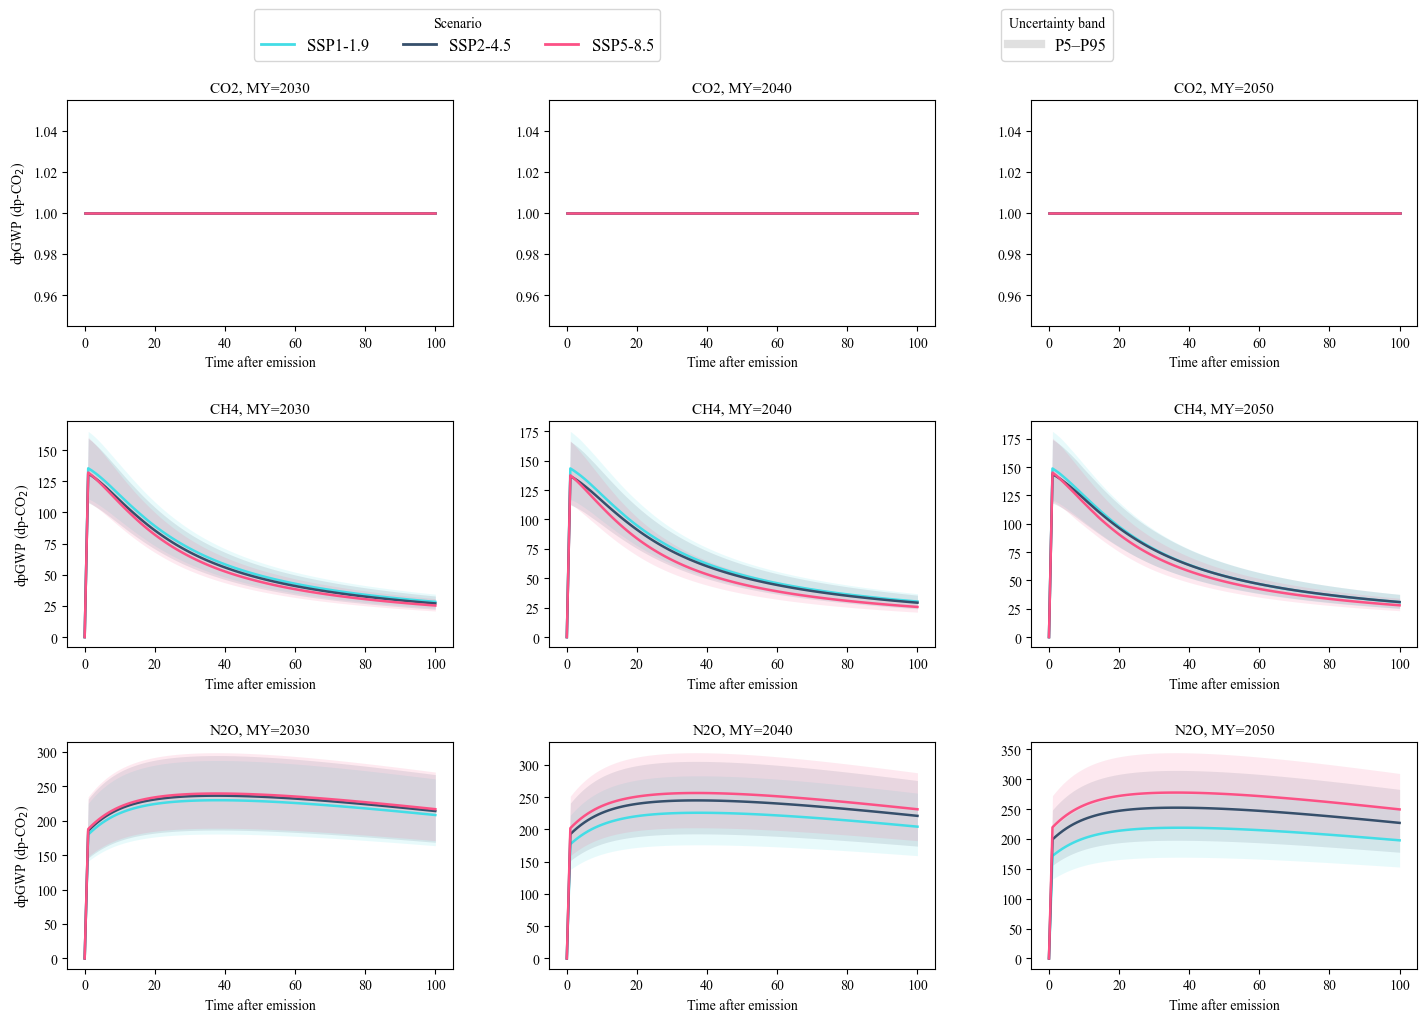

In [7]:
long_modB_preview = wide_to_long_for_benchmark(
    df_modB, metric_suffix=META["suffix"], value_label="value", approach_name="Module B"  #IPCC analytical impulse response function
)

plot_single_metric_panels_with_uncertainty(
    df_metric=long_modB_preview,
    df_unc=unc_modB,
    ylabel=META["panel_ylabel"],
)


## B. Module C

In [9]:
metric_results_modC = load_metric_pointvalue_dict(
    metric_dir=metric_dir_modC,
    filename_template=filename_template_modC,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
    sheet_template=META["sheet_template"],
    len_cf=len_cf,
)

metric_ensmb_modC = load_metric_ensemble_dict(
    metric_dir=metric_dir_modC,
    filename_template=filename_template_modC,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
    ensmb_sheet_template=META["ensmb_sheet_template"],
    len_cf=len_cf,
)

df_modC = build_metric_dataframe(
    metric_results=metric_results_modC,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
)

unc_modC = build_uncertainty_long_df(metric_ensmb_modC, metric_suffix=META["suffix"])
print(df_modC.shape, unc_modC.shape)
df_modC.head()


(909, 3) (2727, 8)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                 
119 2030      0         1.0    0.000000    0.000000
              1         1.0  137.246894  180.979604
              2         1.0  136.641821  186.331567
              3         1.0  135.332017  190.469524
              4         1.0  133.445501  194.059480

In [ ]:
long_modC_preview = wide_to_long_for_benchmark(
    df_modC, metric_suffix=META["suffix"], value_label="value", approach_name="Module C"
)

plot_single_metric_panels_with_uncertainty(
    df_metric=long_modC_preview,
    df_unc=unc_modC,
    ylabel=META["panel_ylabel"],
)


## C. Benchmark Module B vs Module C

In [10]:
benchmark_df = build_benchmark_dataframe(
    df_modB=df_modB,
    df_modC=df_modC,
    metric_suffix=META["suffix"],
    value_label=META["value_label"],
)

benchmark_unc_df = build_benchmark_uncertainty_dataframe(
    unc_modB=unc_modB,
    unc_modC=unc_modC,
)

print("benchmark_df shape:", benchmark_df.shape)
print("benchmark_unc_df shape:", benchmark_unc_df.shape)
display(benchmark_df.head(12))
display(benchmark_unc_df.head(12))


benchmark_df shape: (2727, 10)
benchmark_unc_df shape: (2727, 12)


,SSP,ModelYear,Year,Gas,dpGWP_ModB,dpGWP_ModC,abs_diff,abs_diff_abs,pct_diff_vs_ModB,pct_diff_abs
0,119,2030,0,CO2,1.0,1.0,0.0,0.0,0.0,0.0
1,119,2030,1,CO2,1.0,1.0,0.0,0.0,0.0,0.0
2,119,2030,2,CO2,1.0,1.0,0.0,0.0,0.0,0.0
3,119,2030,3,CO2,1.0,1.0,0.0,0.0,0.0,0.0
4,119,2030,4,CO2,1.0,1.0,0.0,0.0,0.0,0.0
5,119,2030,5,CO2,1.0,1.0,0.0,0.0,0.0,0.0
6,119,2030,6,CO2,1.0,1.0,0.0,0.0,0.0,0.0
7,119,2030,7,CO2,1.0,1.0,0.0,0.0,0.0,0.0
8,119,2030,8,CO2,1.0,1.0,0.0,0.0,0.0,0.0
9,119,2030,9,CO2,1.0,1.0,0.0,0.0,0.0,0.0


,SSP,ModelYear,Year,Gas,lower_ModB,upper_ModB,central_ModB,n_ens_ModB,lower_ModC,upper_ModC,central_ModC,n_ens_ModC
0,119,2030,0,CH4,0.000000,0.000000,0.000000,1001,0.000000,0.000000,0.000000,1001
1,119,2030,1,CH4,110.979733,165.010538,135.387885,1001,112.417147,166.756261,137.246894,1001
2,119,2030,2,CH4,109.589853,162.822973,133.630280,1001,112.061089,165.934175,136.641821,1001
3,119,2030,3,CH4,107.999953,160.338969,131.589825,1001,110.915921,163.972771,135.332017,1001
4,119,2030,4,CH4,106.187412,157.554072,129.387324,1001,109.453896,161.633339,133.445501,1001
5,119,2030,5,CH4,104.220761,154.569711,126.986605,1001,107.708350,158.718743,131.122994,1001
6,119,2030,6,CH4,102.212688,151.407514,124.498633,1001,105.691037,155.530618,128.547847,1001
7,119,2030,7,CH4,100.127945,148.209285,121.890326,1001,103.601666,152.358611,125.864570,1001
8,119,2030,8,CH4,97.939965,144.928536,119.186769,1001,101.495190,149.066462,123.113246,1001
9,119,2030,9,CH4,95.708479,141.706833,116.469097,1001,99.359209,145.738578,120.407473,1001


In [11]:
summary_stats, summary_by_gas = summarize_benchmark(
    benchmark_df=benchmark_df,
    value_label=META["value_label"],
)

display(summary_stats)
display(summary_by_gas)


,Gas,SSP,ModelYear,mean_ModB,mean_ModC,mean_abs_diff,mean_abs_diff_abs,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs,...,abs_diff_H20,pct_diff_H20,ModB_H50,ModC_H50,abs_diff_H50,pct_diff_H50,ModB_H100,ModC_H100,abs_diff_H100,pct_diff_H100
0,CH4,119,2030,60.328206,62.223533,1.895326,1.895326,4.136389,2.932150,4.042166,...,3.386288,3.800795,49.388868,50.998883,1.610015,3.259874,28.246934,28.693328,0.446394,1.580328
1,CH4,245,2030,57.914000,61.105465,3.191465,3.226058,6.403658,4.904622,8.823046,...,6.371584,7.444630,47.257481,50.756420,3.498939,7.403990,27.020272,26.660597,-0.359675,-1.331130
2,CH4,585,2030,55.427798,55.681074,0.253276,2.835757,4.621848,-2.420643,17.174148,...,4.196308,5.109410,44.390473,44.601231,0.210758,0.474783,25.306955,20.960701,-4.346254,-17.174148
3,CH4,119,2040,64.306870,64.823646,0.516776,0.739661,3.538300,0.283224,2.627994,...,1.293790,1.363172,52.789279,52.857204,0.067924,0.128671,30.223159,29.862711,-0.360447,-1.192620
4,CH4,245,2040,61.923235,63.516183,1.592948,2.168650,4.691392,1.455675,5.245333,...,4.499374,4.926532,51.013885,52.521781,1.507896,2.955854,29.241300,27.773668,-1.467632,-5.019040
5,CH4,585,2040,56.561248,58.137761,1.576513,3.324760,6.739732,0.269590,14.101971,...,6.628148,7.903875,44.946427,46.533205,1.586778,3.530376,25.637643,22.022230,-3.615413,-14.101971
6,CH4,119,2050,65.972209,65.722567,-0.249642,0.776714,2.758194,-0.960715,2.271922,...,0.043901,0.045033,53.932430,53.223236,-0.709194,-1.314968,30.823137,30.122859,-0.700278,-2.271922
7,CH4,245,2050,65.311659,65.493270,0.181611,1.693728,3.197570,-1.099489,7.477725,...,2.566528,2.667278,53.885793,53.830352,-0.055441,-0.102886,30.918264,28.606282,-2.311983,-7.477725
8,CH4,585,2050,61.180129,60.812994,-0.367135,2.964069,4.925011,-3.523003,17.553233,...,4.317460,4.766854,49.066144,48.549916,-0.516228,-1.052106,28.057570,23.132560,-4.925011,-17.553233
9,CO2,119,2030,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000


,Gas,mean_ModB,mean_ModC,mean_abs_diff,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs
0,CH4,60.991706,61.946277,0.954571,6.739732,0.204601,17.553233
1,CO2,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,N2O,231.922829,194.112861,-37.809967,109.807695,-15.815733,44.012593


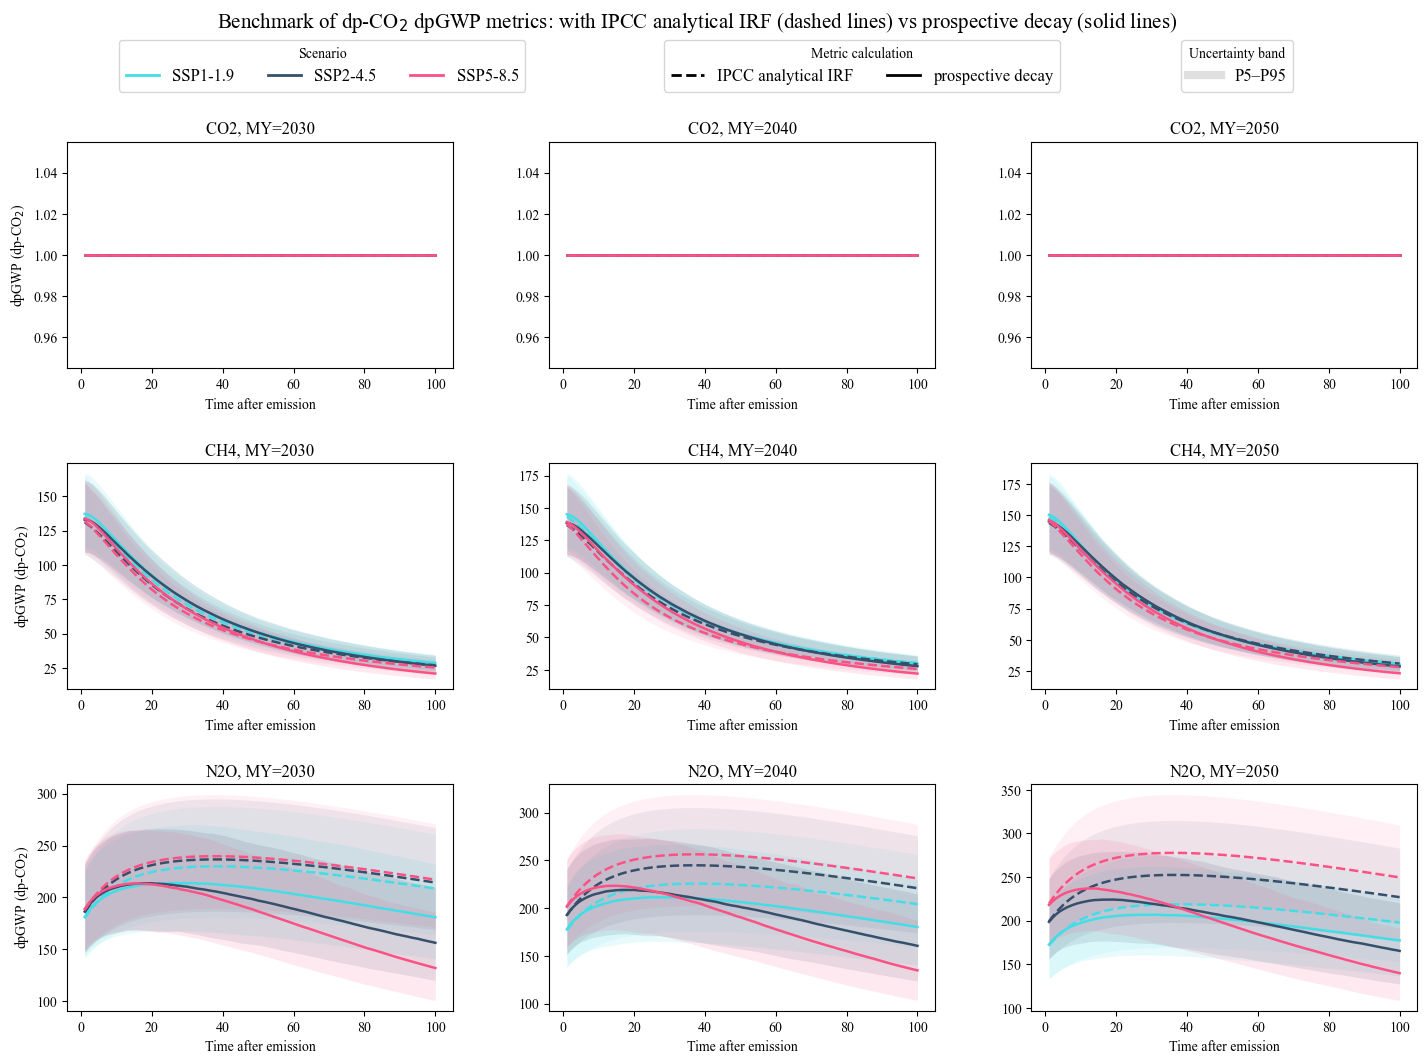

In [14]:
plot_benchmark_3x3_with_uncertainty(
    benchmark_df=benchmark_df,
    benchmark_unc_df=benchmark_unc_df,
    value_label=META["value_label"],
    panel_ylabel=META["panel_ylabel"],
    suptitle=META["suptitle"],
)